In [ ]:
 ============================================
 LINEAR REGRESSION COMPLETE WORKFLOW
 ============================================

1. Gather Data
 --------------------------------------------
 Collect dataset from CSV, Excel, Database,
 APIs, Kaggle, company data, etc.


2. Exploratory Data Analysis (EDA)
 --------------------------------------------
 Understand dataset using:
 - shape()
 - info()
 - describe()
 - null value checking
 - duplicate checking
 - outlier detection
 - correlation analysis
 - visualization (heatmap, histogram, scatterplot)


3. Data Cleaning & Preprocessing
 --------------------------------------------
 - Handle missing values
 - Remove duplicates
 - Handle outliers
 - Encode categorical data
 - Feature scaling if needed


4. Feature Selection
 --------------------------------------------
 Select important independent variables (features = x)
 that affect target variable.(y)

 Methods:
 - Correlation
 - Heatmap
 - Domain knowledge
 - Statistical methods


5. Define X and y
 --------------------------------------------

 X = Independent variables (features)
 y = Dependent variable (target)

 Example:
 X = house size, bedrooms
 y = house price


6. Train-Test Split
 --------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


7. Check Linear Regression Assumptions
 --------------------------------------------
 Usually checked before or after training.

 Important assumptions:
 - Linear relationship
 - No multicollinearity
 - Normality of residuals
 - Homoscedasticity


 Tools:
 - Scatter plots
 - Residual plots
 - VIF
 - Histogram / QQ plot


8. Import and Train Model
 --------------------------------------------

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)


9. Prediction on Training Data
 --------------------------------------------

y_train_pred = lr.predict(X_train)


10. Evaluate Training Performance
 --------------------------------------------

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print(mean_absolute_error(y_train, y_train_pred))
print(mean_squared_error(y_train, y_train_pred))
print(r2_score(y_train, y_train_pred))


11. Prediction on Testing Data
 --------------------------------------------

y_test_pred = lr.predict(X_test)


12. Actual vs Predicted Comparison
 --------------------------------------------

import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
})

print(comparison.head())


13. Evaluate Testing Performance
 --------------------------------------------

print("MAE:", mean_absolute_error(y_test, y_test_pred))

print("MSE:", mean_squared_error(y_test, y_test_pred))

print("RMSE:",
      mean_squared_error(
          y_test,
          y_test_pred,
          squared=False
      ))

print("R2 Score:",
      r2_score(y_test, y_test_pred))

14. Final Interpretation
 --------------------------------------------
 Compare train vs test performance.

 If:
 - Train score high
 - Test score similar

 => Good Model

 If:
 - Train score very high
 - Test score low

 => Overfitting

 If:
 - Both scores low

 => Underfitting

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### 1. Data Gathering

In [2]:
df = pd.read_csv(r"C:\Velocity\Practice\Data_Science\Linear_Regression\medical_insurance.csv")
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### 2. EDA(Exploratory Data Analysis)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


### 3. Data Preprocessing

In [4]:
print(df["smoker"].unique())
print(df["region"].unique())
print(df["gender"].unique())

<StringArray>
['yes', 'no']
Length: 2, dtype: str
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
<StringArray>
['female', 'male']
Length: 2, dtype: str


In [ ]:
Linear Regression only understands the numerical data ,thus we will convert 
categorical data into numreical form using onehot encoding

In [5]:
df["smoker"] = df["smoker"].replace({ "yes":1, "no":0}, inplace = True)
df["gender"] = df["gender"].replace({ "male":1, "female":0}, inplace = True)
df

,age,gender,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [6]:
# onehot encoding region column
df = pd.get_dummies(df, columns = ['region'], dtype = int)
df

,age,gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


### 4. Feature Selection

In [ ]:
-> Input Features(X) are independent variables used for prediction.
=> age,gender,childer,smoker,charges,and region columns are input freatures

-> Target Variable (y) is the output we want to predict.
=> charge is target variable/output

### 5. Defining X and Y

In [7]:
x = df.drop(labels= "charges", axis = 1)
y = df['charges']

In [8]:
print(y)
pd.DataFrame(x)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


,age,gender,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,0,1
1,18,1,33.770,1,0,0,0,1,0
2,28,1,33.000,3,0,0,0,1,0
3,33,1,22.705,0,0,0,1,0,0
4,32,1,28.880,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,0,1,0,0
1334,18,0,31.920,0,0,1,0,0,0
1335,18,0,36.850,0,0,0,0,1,0
1336,21,0,25.800,0,0,0,0,0,1


### 6. Train test split

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y, train_size = 0.80, random_state = 23)
x_train

,age,gender,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
708,31,0,30.495,3,0,1,0,0,0
45,55,1,37.300,0,0,0,0,0,1
434,31,1,28.595,1,0,0,1,0,0
995,39,0,23.275,3,0,1,0,0,0
1299,19,0,25.745,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
31,18,0,26.315,0,0,1,0,0,0
950,57,1,18.335,0,0,1,0,0,0
1064,29,0,25.600,4,0,0,0,0,1
742,53,1,34.105,0,1,1,0,0,0


In [10]:
x.shape

(1338, 9)

### 7. Check Linear Regression Assumptions

In [36]:
# 1. Linearity done before model training
# 2. No MultiColinearity also done before model training

<function matplotlib.pyplot.show(close=None, block=None)>

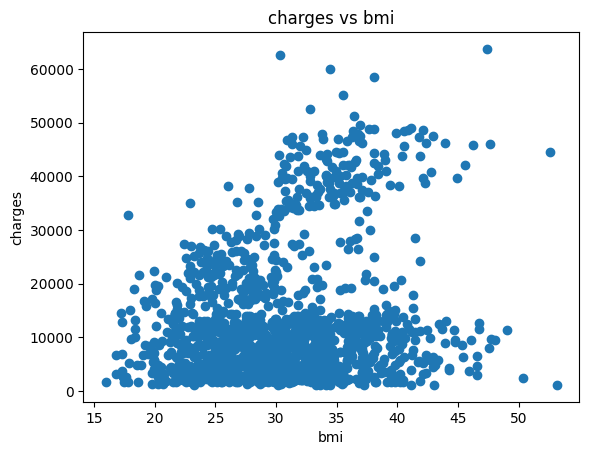

In [11]:
#1st linearity assumption for single input feature
plt.scatter(df["bmi"],df["charges"])
plt.xlabel("bmi")
plt.ylabel("charges")
plt.title("charges vs bmi")
plt.show

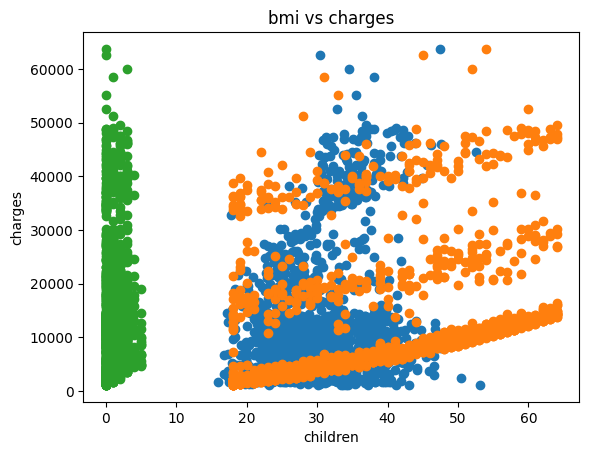

In [12]:
# for multiple input feature 
cols = ["bmi","age","children"]
for col in cols:
    plt.scatter(df[col],df["charges"]) 
    plt.xlabel(col)
    plt.ylabel("charges")
    plt.title(f"bmi vs {"charges"}")
    plt.show

In [13]:
#2. No Multicolinearity assumptions checking by using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

### 8. Model Training

In [13]:
lin_reg = LinearRegression()
lin_reg.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
x_train

,age,gender,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
708,31,0,30.495,3,0,1,0,0,0
45,55,1,37.300,0,0,0,0,0,1
434,31,1,28.595,1,0,0,1,0,0
995,39,0,23.275,3,0,1,0,0,0
1299,19,0,25.745,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
31,18,0,26.315,0,0,1,0,0,0
950,57,1,18.335,0,0,1,0,0,0
1064,29,0,25.600,4,0,0,0,0,1
742,53,1,34.105,0,1,1,0,0,0


In [15]:
y_train

708      6113.23105
45      20630.28351
434      4243.59005
995      7986.47525
1299     2710.82855
           ...     
31       2198.18985
950     11534.87265
1064     5708.86700
742     43254.41795
595      8823.98575
Name: charges, Length: 1070, dtype: float64

In [16]:
# predicted values
y_pred_train = lin_reg.predict(x_train)

### 9. Comparison of Actual and Predicted Values

In [17]:
comparison = pd.DataFrame({
    "Actual_values": y_train,
    "Predicted_values": y_pred_train
})
comparison

,Actual_values,Predicted_values
708,6113.23105,8163.792963
45,20630.28351,13213.241768
434,4243.59005,5858.396250
995,7986.47525,7676.875981
1299,2710.82855,2051.894597
...,...,...
31,2198.18985,2033.924867
950,11534.87265,8778.775638
1064,5708.86700,5034.840087
742,43254.41795,37138.268735


In [18]:
#3. Normality of residuals Assumption (1st calculate residuals)
residuals = y_train - y_pred_train

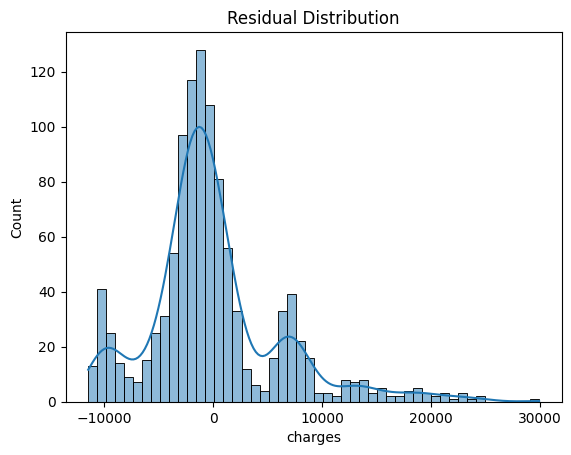

In [19]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

<Axes: ylabel='charges'>

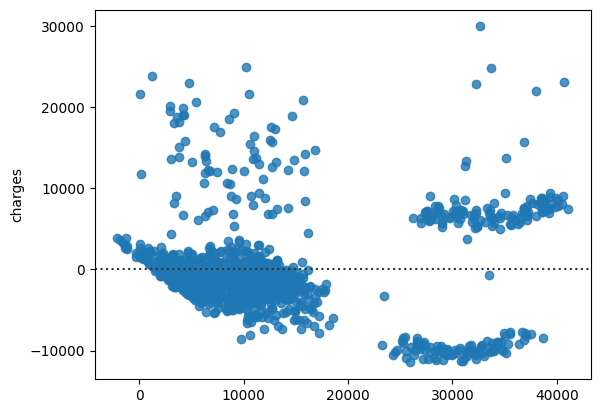

In [20]:
#4. Homoscadasticity (to calculate we use residuals)
sns.residplot(
    x=y_pred_train,
    y=residuals)

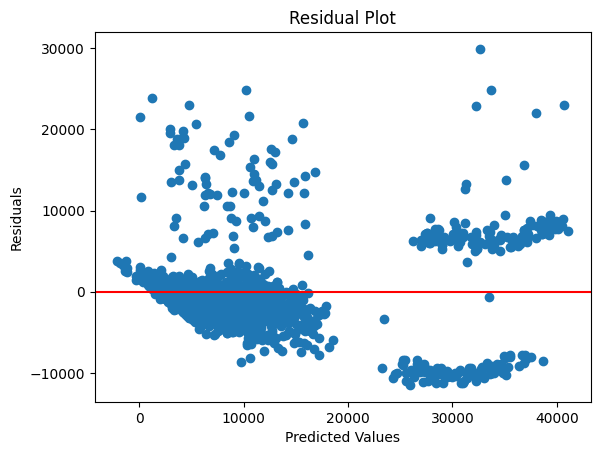

In [21]:
plt.scatter(y_pred_train, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### 10.Model Evaluation

In [22]:
print("MAE is:",mean_absolute_error(y_train,y_pred_train))
print("MSE is:",mean_squared_error(y_train,y_pred_train))
print("RMSE is:",np.sqrt(mean_squared_error(y_train,y_pred_train)))
print("R_sqr is:",r2_score(y_train,y_pred_train))

MAE is: 4212.153489540199
MSE is: 37056761.48533833
RMSE is: 6087.426507592378
R_sqr is: 0.7493255146273343


### 11. Predictions on Testing Model(test model training)

In [23]:
lin_reg.fit(x_test,y_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred_test = lin_reg.predict(x_test)

### 12. Actual vs Predicted comparison

In [25]:
compare = pd.DataFrame({
    "Y_Actual_values": y_test,
    "Y_predicted_values": y_pred_test
})
compare

,Y_Actual_values,Y_predicted_values
918,13041.92100,14614.313038
755,5031.26955,5034.972608
207,20984.09360,29492.675723
520,25656.57526,10061.414697
695,3201.24515,7483.076578
...,...,...
298,38746.35510,31279.089080
369,3481.86800,2392.370478
153,19964.74630,29487.646222
264,20462.99766,15362.041334


### 13. test Model evaluation

In [26]:
print("MAE is:",mean_absolute_error(y_test,y_pred_test))
print("MSE is:",mean_squared_error(y_test,y_pred_test))
print("RMSE is:",np.sqrt(mean_squared_error(y_test,y_pred_test)))
print("R_sqr is:",r2_score(y_test,y_pred_test))

MAE is: 3997.4447181933
MSE is: 32958759.722548187
RMSE is: 5740.972018965794
R_sqr is: 0.7656823686771154


### Save Model

In [30]:
import pickle

with open("LR_med_ins.pkl","wb") as f:
    pickle.dump(lin_reg,f)

### Save Columns data

In [31]:
import json

In [32]:
df['gender'].replace({"male":1, "female":0}, inplace = True)
df['smoker'].replace({"yes":1, "no":0}, inplace = True)
df

,age,gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


In [33]:
med_ins_json = {"gender" : {"male":1, "female":0},"smoker" : {"yes":1, "no":0}}
med_ins_json

{'gender': {'male': 1, 'female': 0}, 'smoker': {'yes': 1, 'no': 0}}

In [34]:
with open("med_ins_column_data.json", "w") as f:
    json.dump(med_ins_json, f)